## Prepare dataset

In [1]:
import torch 

print(torch.__version__)
print(torch.cuda.is_available())

2.4.1+cu121
True


In [17]:
import os

In [18]:
DATASET_NAME = "CT_TAS_GRENOBLE_TEST"
DATA_PATH = "/data_network/summer_projects/geninana/Current/2020_AINI-Stroke_TC_BL/2025_AVA_Stroke/CT/tsa_50_nifti_test"


#these functions are to define for each new dataset, unless fixing a rule
#they allow to define a clear association between the data path of a brain image and the corresponding brain/vessel mask
#the brain mask is not mandatory, if not present just return None
import utils
def img_path_to_brain_path(img_path):
    return img_path.replace(".nii.gz", "_brain.nii.gz")
def img_path_to_weight_path(img_path):
    return None
def img_path_to_vessel_path(img_path):
    return img_path.replace(".nii.gz", "_vessel.nii.gz")

utils.img_path_to_brain_path = img_path_to_brain_path
utils.img_path_to_weight_path = img_path_to_weight_path 
utils.img_path_to_vessel_path = img_path_to_vessel_path 

#this regex works as a filter in case you have unnecessary .nii files in your dataset folder
PATH_RULE = "^.*.nii.gz$"

#if you have some outliers you want to discard, you can specify it in the list below
OUTLIERs = []

#if you need to preprocess also images with no vessel masks set the following flag to False
VESSELs_REQUIRED = False
#this parameter is to unify the orientation of our images
#set it True if you notice in the examples shown below that the nose is oriented downward and not upward
utils.do_flip = True
#this parameter is to specify whether to discard slices which do not contain any portion of the brain or keep them
DISCARD_EXTRA_SLICES = False

### Extract paths

In [19]:
import os

from utils import search_nii, extract_paths, load_info_from_checkpoint

In [20]:
if not os.path.isfile(f"info_{DATASET_NAME}.pkl"):
    info = {
        "train": extract_paths(path_rule=PATH_RULE),
        "val": None,
        "test": None,
    }
    search_nii(DATA_PATH, info["train"])
else:
    print("Loading info from ", f"info_{DATASET_NAME}.pkl")
    info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

### Display examples

In [21]:
import random

from utils import print_bold, load_and_display_middle_slice

[Example 01]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 512 512 521   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.        0.550781  0.550781  0.625     0.        0.        0.
  0.      ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'Time=141228.853'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.0
quatern_c       : 1.0
quatern_d       : 0.0
qoffset_x       : 141.0
qoffset_y       : 

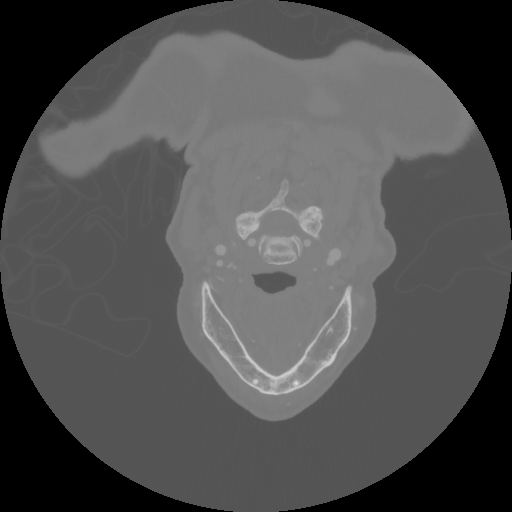

[Example 02]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 512 512 508   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.        0.488281  0.488281  0.625     0.        0.        0.
  0.      ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'Time=212621.628'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.0
quatern_c       : 1.0
quatern_d       : 0.0
qoffset_x       : 125.0
qoffset_y       : 

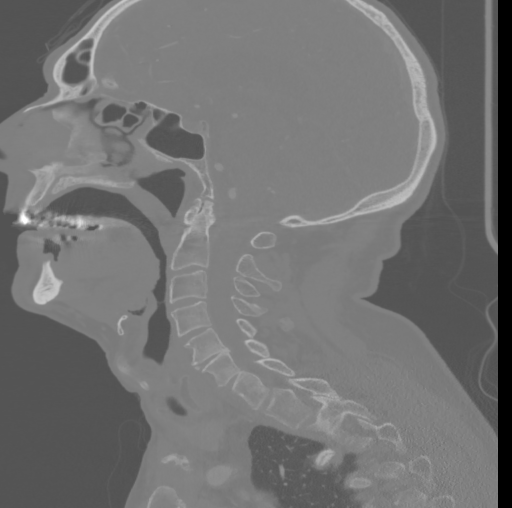

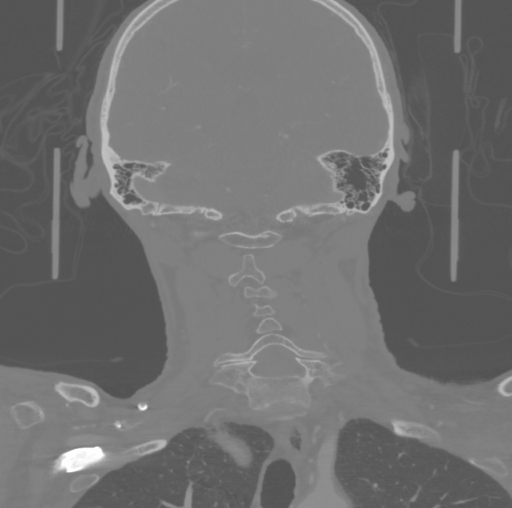

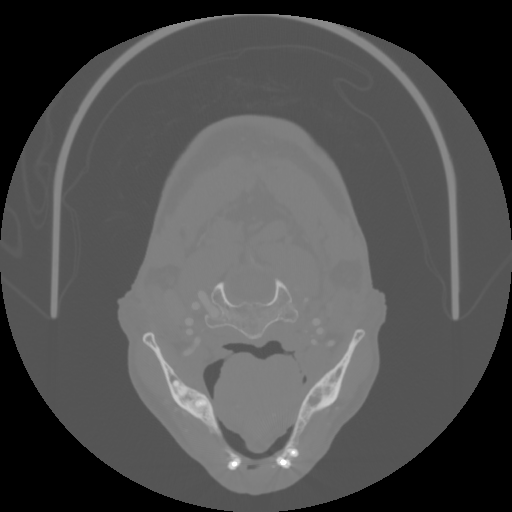

In [22]:
print_bold("[Example 01]")
random.seed(67)
load_and_display_middle_slice(random.choice(info["train"].paths), display_header=True)

print_bold("[Example 02]")
random.seed(112)
load_and_display_middle_slice(random.choice(info["train"].paths), axis=[0,1,2], display_header=True)

### Split train/val/test

In [23]:
from utils import is_medical_volume

In total, there are

In [24]:
IMGs = sum([
    info["train"].paths,
    info["val"].paths if info["val"] is not None else [],
    info["test"].paths if info["test"] is not None else []
], [])

len(IMGs)

5

volumes. First, we discard the outliers:

In [25]:
IMGs = [img_path for img_path in IMGs if os.path.basename(img_path) not in OUTLIERs]

len(IMGs)

5

We have vessel annotations for

In [26]:
HAVE_VESSELs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_vessel_path(img_path))
]

if complete_flag:
    HAVE_VESSELs = [
        img_path for img_path in IMGs if is_medical_volume(img_path_to_vessel_path_complete(img_path))
    ]


len(HAVE_VESSELs)

0

of them. With a chosen ratio of 70-15-15, we select

In [27]:
COUNT_TEST = len(HAVE_VESSELs if VESSELs_REQUIRED else IMGs) * 100 // 100
COUNT_TEST

5

images to be part of the validation/testing set.

In case brain masks are available, we collect them too.

In [28]:
HAVE_BRAINs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_brain_path(img_path))
]

len(HAVE_BRAINs)

0

Finally, we randomly split our dataset. 

In [29]:
random.seed(0)

VAL_IMGs = []

print("val: ", [os.path.basename(img) for img in VAL_IMGs])

random.seed(1)

TEST_IMGs = random.sample(sorted([img for img in IMGs]), COUNT_TEST)

print("test: ", [os.path.basename(img) for img in TEST_IMGs])

TRAIN_IMGs = [img for img in (HAVE_VESSELs if VESSELs_REQUIRED else IMGs) if img not in VAL_IMGs and img not in TEST_IMGs]

print("train: ", [os.path.basename(img) for img in TRAIN_IMGs])

val:  []
test:  ['433242_Dataset_aini-stroke-13633_433242_TSA_Carotides_20250129122014.nii.gz', '433116_Dataset_aini-stroke-15486_433116_TSA_TSA_20250129123557.nii.gz', '433507_Dataset_aini-stroke-16297_433507_TSA_Carotides_20250129114715.nii.gz', '433437_Dataset_aini-stroke-11525_433437_TSA_TSA_20250129115438.nii.gz', '433406_Dataset_aini-stroke-12081_433406_TSA_TSA_20250129120309.nii.gz']
train:  []


### Extract spacings and shapes

In [30]:
from utils import extract_info_and_masks, loop_nii, display_info, get_target_spacing

In [31]:
info = {
    "train": extract_info_and_masks(path_rule=PATH_RULE),
    "val": extract_info_and_masks(path_rule=PATH_RULE),
    "test": extract_info_and_masks(path_rule=PATH_RULE),
}

loop_nii(TRAIN_IMGs, info["train"])
loop_nii(VAL_IMGs, info["val"])
loop_nii(TEST_IMGs, info["test"])

In [32]:
#display_info(info["train"], info["val"])
display_info(info["test"],info["test"])

,#volumes,#slices,spacing median,spacing range,shape median,shape range
TRAIN,5,2649,[000.49 000.49 000.62],[000.49 000.49 000.62] - [000.55 000.55 000.62],[512.00 490.00 523.00],[512.00 456.00 508.00] - [512.00 512.00 560.00]
VAL,5,2649,[000.49 000.49 000.62],[000.49 000.49 000.62] - [000.55 000.55 000.62],[512.00 490.00 523.00],[512.00 456.00 508.00] - [512.00 512.00 560.00]


In [33]:
import numpy as np

try:
    SPACING = get_target_spacing(
        info["train"].spacings + info["val"].spacings,
        info["train"].shapesAfterCropping() + info["val"].shapesAfterCropping()
    )
    print(SPACING)
except:
    SPACING = np.array([0.4453125 , 0.4453125 , 0.70001221])


SPACING

array([0.4453125 , 0.4453125 , 0.70001221])

In [34]:
from utils import save_info_to_checkpoint

save_info_to_checkpoint(info, f"info_{DATASET_NAME}.pkl")

### Crop, Metadata, Resize, Empty Slices Removal, Standardization

In [35]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [36]:
import os

from utils import print_bold, preprocessing_loop

In [37]:
from pathlib import Path


OUT_DIR = f"/home/geninana/data_ssd/DqnieleF/A2V_experiments/{DATASET_NAME}_preprocessed"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

In [38]:
print_bold("Training")
preprocessing_loop(
    info["train"],
    os.path.join(OUT_DIR,"numpy", "train"),
    target_spacing=SPACING,
    discard_extracerebral_slices=DISCARD_EXTRA_SLICES,
    crop_CT=250
)

print_bold("Validation")
preprocessing_loop(
    info["val"],
    os.path.join(OUT_DIR,"numpy", "val"),
    target_spacing=SPACING,
    discard_extracerebral_slices=DISCARD_EXTRA_SLICES,
    crop_CT=250
)

print_bold("Testing")
preprocessing_loop(
    info["test"],
    os.path.join(OUT_DIR,"numpy", "test"),
    target_spacing=SPACING,
    discard_extracerebral_slices=DISCARD_EXTRA_SLICES,
    crop_CT=250 # Crop the first 250 slices
)

Training


0it [00:00, ?it/s]


Validation


0it [00:00, ?it/s]


Testing


...

Slices processed: 763
(512, 512, 508)
Target spacing: [0.4453125  0.4453125  0.70001221]
Current spacing: [0.488281 0.488281 0.625   ]
New shape: [561 561 230]
Resized shape: (561, 561, 230)
PASSED New shape: [512, 512]
New shape: [512 512 230]
Resized shape: (512, 512, 230)


 80%|████████  | 4/5 [04:20<01:03, 63.52s/it]

Slices processed: 993
(512, 512, 537)
Target spacing: [0.4453125  0.4453125  0.70001221]
Current spacing: [0.488281 0.488281 0.625   ]
New shape: [561 514 256]
Resized shape: (561, 514, 256)
PASSED New shape: [512, 512]
New shape: [512 512 256]
Resized shape: (512, 512, 256)


100%|██████████| 5/5 [05:23<00:00, 64.66s/it]

Slices processed: 1249


In [39]:
from utils import save_info_to_checkpoint

save_info_to_checkpoint(info, f"info_{DATASET_NAME}.pkl")

### Outliers removal and slices extraction

In [40]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [41]:
import os

from utils import print_bold, extraction_loop, display_slice

In [42]:
print_bold("Training")
extraction_loop(
    info["train"],
    os.path.join(OUT_DIR,"slices", "train")
)

print_bold("Validation")
extraction_loop(
    info["val"],
    os.path.join(OUT_DIR,"slices", "val")
)

print_bold("Testing")
extraction_loop(
    info["test"],
    os.path.join(OUT_DIR,"slices", "test")
)

Training


0it [00:00, ?it/s]


Validation


0it [00:00, ?it/s]


Testing


100%|██████████| 5/5 [00:06<00:00,  1.34s/it]


In [43]:
from utils import save_info_to_checkpoint

save_info_to_checkpoint(info, f"info_{DATASET_NAME}.pkl")

### Intensity values analysis

In [44]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [45]:
import numpy as np

from utils import intensity_loop, display_intensity
from utils import get_percentile, display_clipped_slice

In [46]:
try:
    print_bold("Training")
    intensity_loop(
        info["train"],
        min_value=min(info["train"].min_values + info["val"].min_values),
        max_value=max(info["train"].max_values + info["val"].max_values)
    )
    display_intensity(info["train"])

    print_bold("Validation")
    intensity_loop(
        info["val"],
        min_value=min(info["train"].min_values + info["val"].min_values),
        max_value=max(info["train"].max_values + info["val"].max_values)
    )
    display_intensity(info["val"])
except:
    print("JUST TESTING")

Training
JUST TESTING


In [47]:
MIN_VALUE =  -1.5739588069435766 
MAX_VALUE = 3.0808791798780533

In [48]:
from utils import save_info_to_checkpoint

save_info_to_checkpoint(info, f"info_{DATASET_NAME}.pkl")

### Normalization, Padding & Cropping, One-Hot Encoding

In [49]:
print(DATASET_NAME)

CT_TAS_GRENOBLE_TEST


In [50]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [51]:
import numpy as np

from utils import display_slice, normalization_loop

In [52]:
print(OUT_DIR)

/home/geninana/data_ssd/DqnieleF/A2V_experiments/CT_TAS_GRENOBLE_TEST_preprocessed


In [53]:
print_bold("Training")
normalization_loop(info["train"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/train", MIN_VALUE, MAX_VALUE)

print_bold("Validation")
normalization_loop(info["val"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/val", MIN_VALUE, MAX_VALUE)

print_bold("Testing")
normalization_loop(info["test"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/test", MIN_VALUE, MAX_VALUE)

Training


0it [00:00, ?it/s]


Validation


0it [00:00, ?it/s]


Testing


100%|██████████| 5/5 [00:18<00:00,  3.61s/it]


In [54]:
np.save(f"{OUT_DIR}/preprocess_map_{DATASET_NAME}.npy", {
    "train": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/train")),
    "val": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/val")),
    "test": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/test")),
})

000


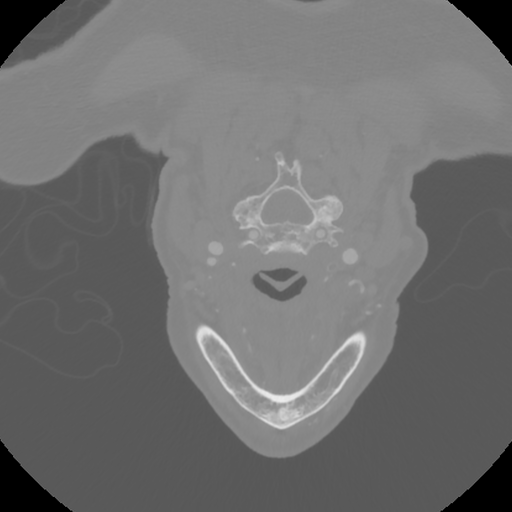

020


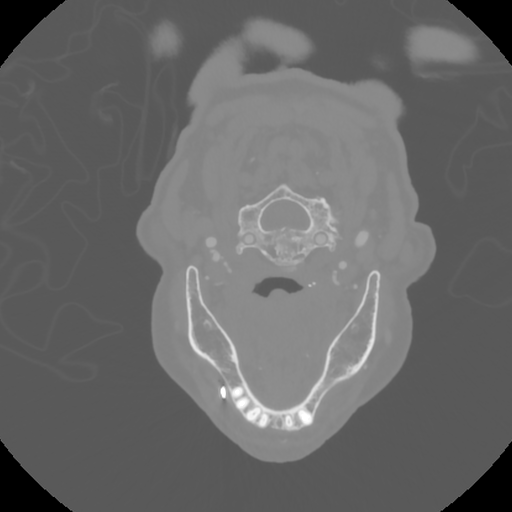

040


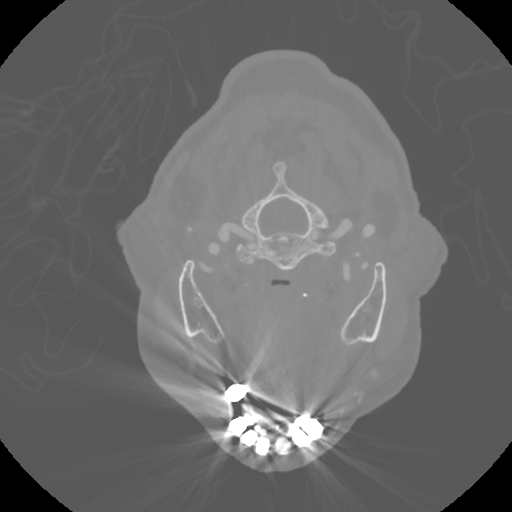

060


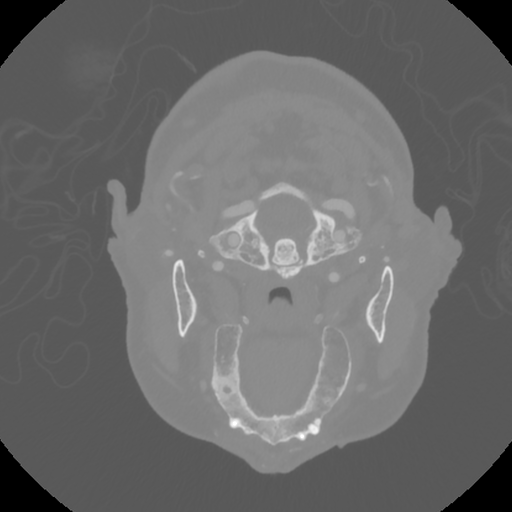

080


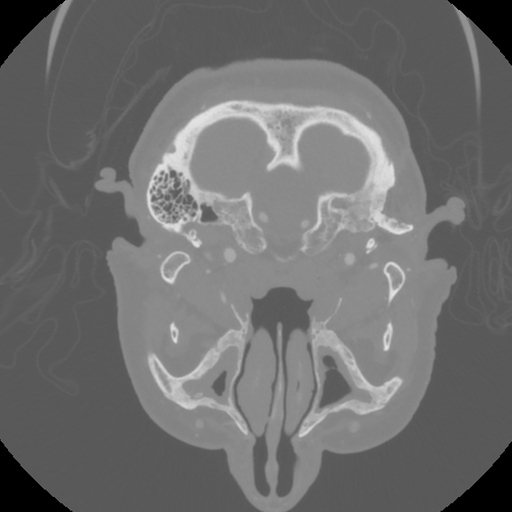

100


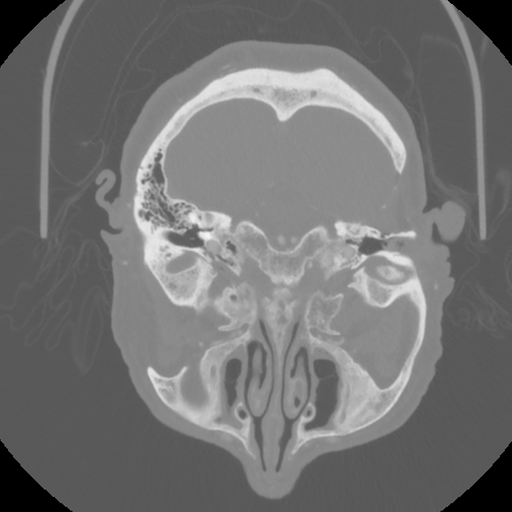

120


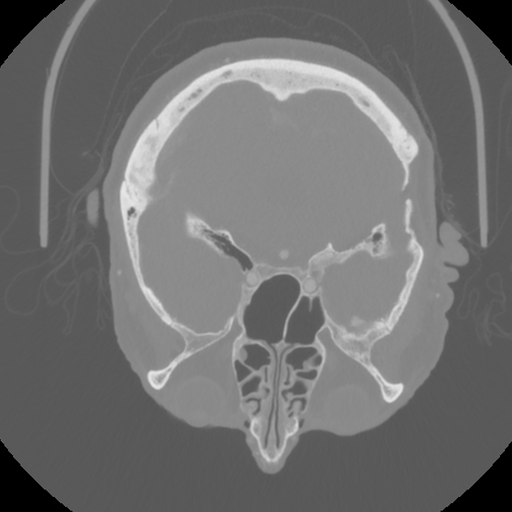

140


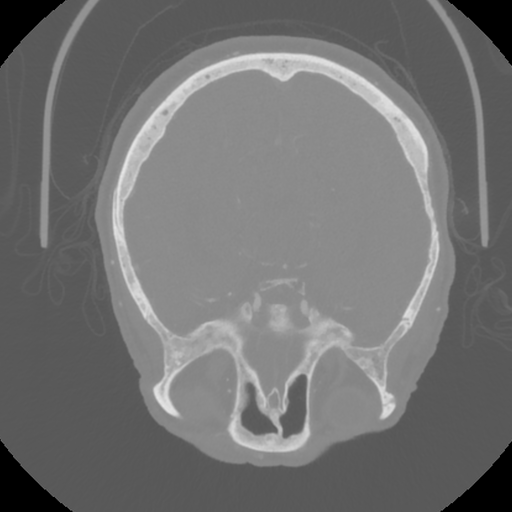

160


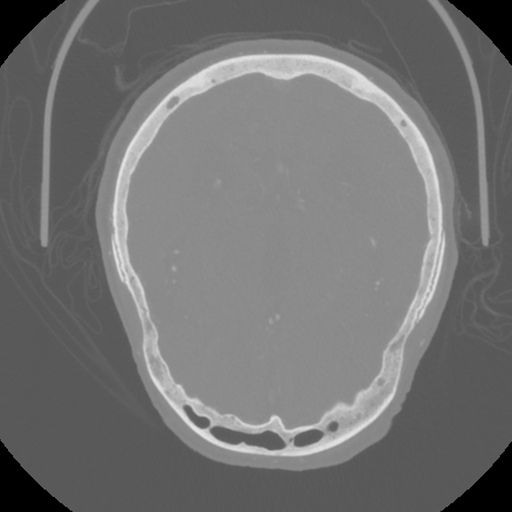

180


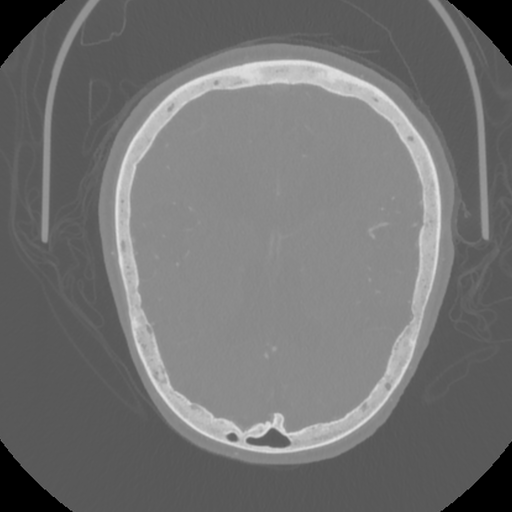

200


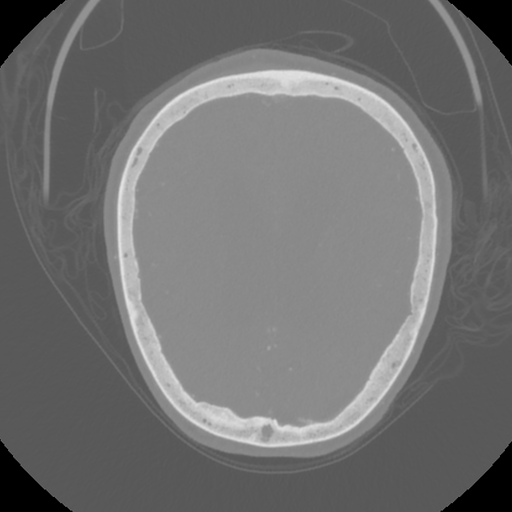

220


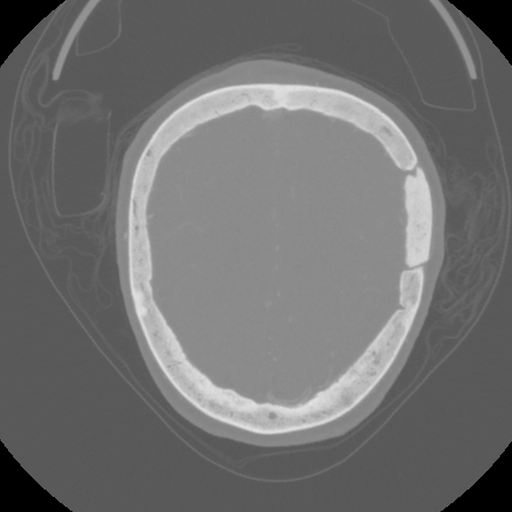

240


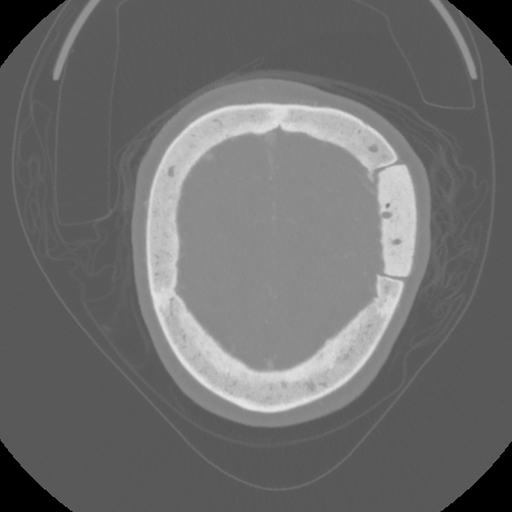

In [57]:
for slice_num in range(0, 250,20):
    # Format slice number with leading zeros
    slice_str = f"{slice_num:03d}"
    print(slice_str)
    # Load the specific slice
    img_example = np.load(
        f"{OUT_DIR}/preprocess_{DATASET_NAME}/test/433116_Dataset_aini-stroke-15486_433116_TSA_TSA_20250129123557_slice{slice_str}.npy", 
        allow_pickle=True
    ).item()

    img_example, msk_example = img_example["data"][:,:,0], img_example["mask"]

    msk_example = np.argmax(msk_example, axis=-1)

    display_slice(img_example, min_val=-1, max_val=1, mask=msk_example/2)